In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [ ]:
np.random.seed(42)

n = 100000

df = pd.DataFrame({
    'gender': np.random.choice([0, 1], n),
    'age': np.random.randint(18, 80, n),
    'hypertension': np.random.choice([0, 1], n),
    'heart_disease': np.random.choice([0, 1], n),
    'smoking_history': np.random.randint(0, 5, n),
    'bmi': np.random.uniform(15, 40, n),
    'HbA1c_level': np.random.uniform(4, 10, n),
    'blood_glucose_level': np.random.randint(70, 300, n)
})

df['diabetes'] = (
    (df['bmi'] > 30) |
    (df['HbA1c_level'] > 6.5) |
    (df['blood_glucose_level'] > 180)
).astype(int)

print("Dataset Shape:", df.shape)

Dataset Shape: (100000, 9)


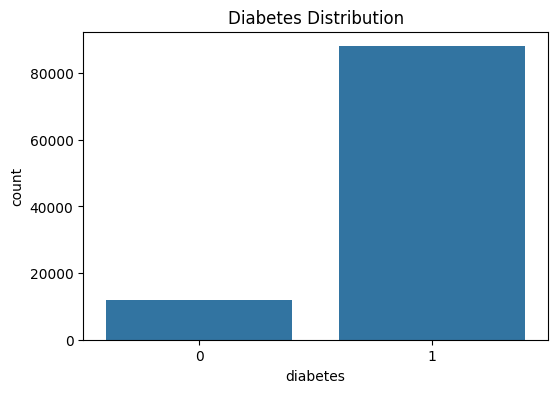

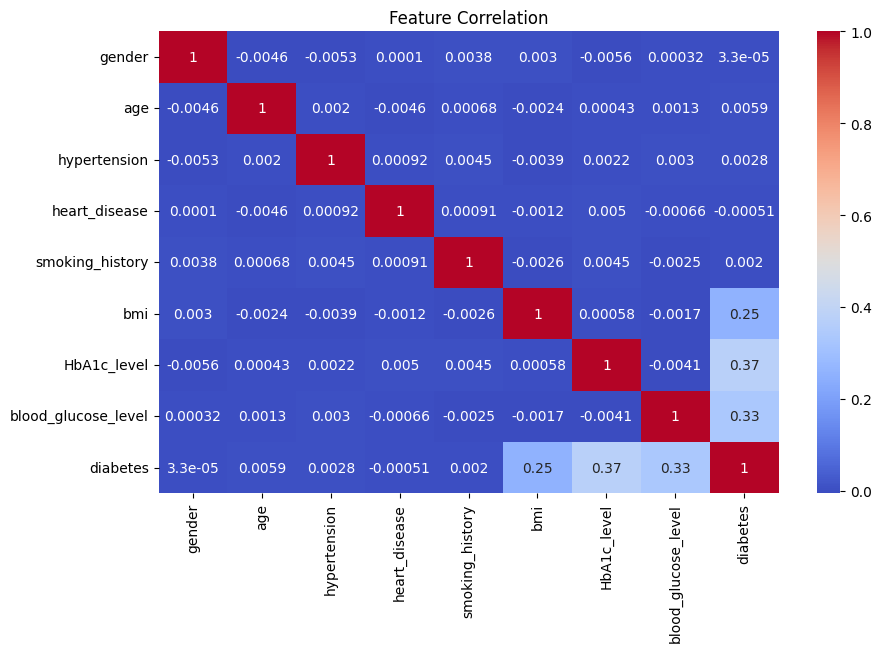

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
}

results = {}
roc_data = {}

In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Report:\n", classification_report(y_test, y_pred))

    # ROC Curve
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_data[name] = (fpr, tpr, roc_auc)


===== Logistic Regression =====
Accuracy: 0.9418
Confusion Matrix:
 [[ 1570   754]
 [  410 17266]]
Report:
               precision    recall  f1-score   support

           0       0.79      0.68      0.73      2324
           1       0.96      0.98      0.97     17676

    accuracy                           0.94     20000
   macro avg       0.88      0.83      0.85     20000
weighted avg       0.94      0.94      0.94     20000


===== Decision Tree =====
Accuracy: 1.0
Confusion Matrix:
 [[ 2324     0]
 [    0 17676]]
Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2324
           1       1.00      1.00      1.00     17676

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


===== Random Forest =====
Accuracy: 1.0
Confusion Matrix:
 [[ 2324     0]
 [    0 17676]]
Report:
               precision    recall  f1

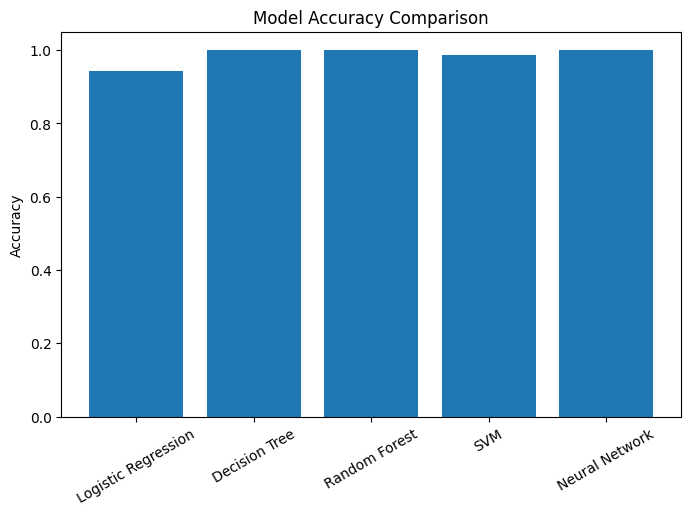

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

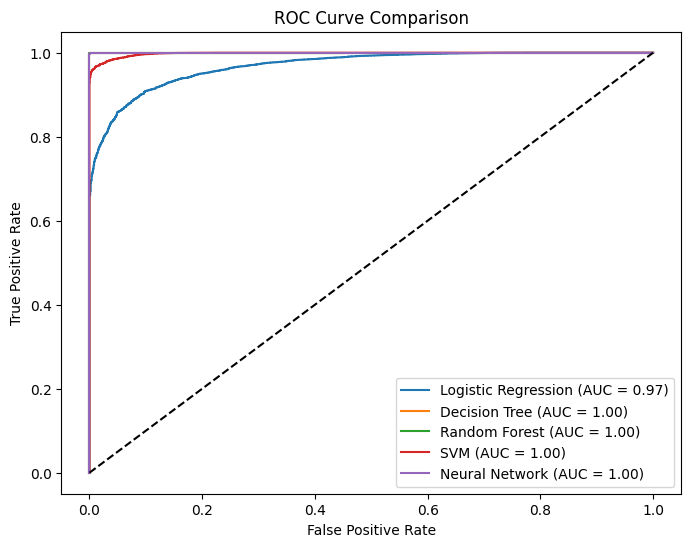

In [ ]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: Decision Tree


In [ ]:
import joblib

joblib.dump(models[best_model], "best_model.pkl")
print("Model saved!")

Model saved!


Dataset Shape: (100000, 9)


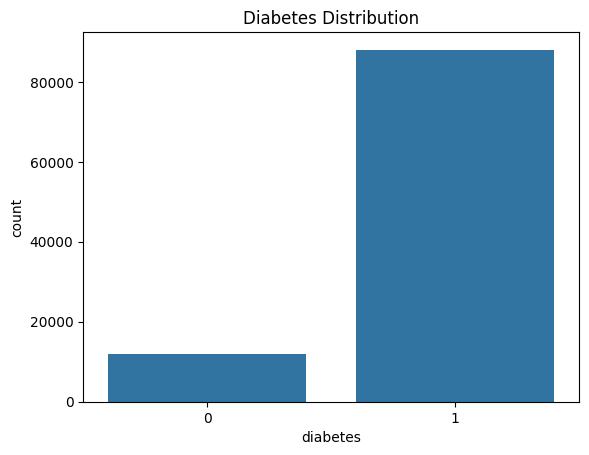

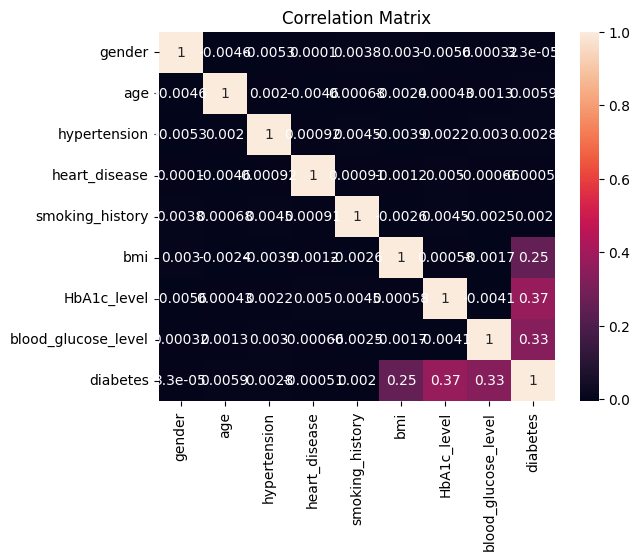


===== Logistic Regression =====
Accuracy: 0.9418
Confusion Matrix:
 [[ 1570   754]
 [  410 17266]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.68      0.73      2324
           1       0.96      0.98      0.97     17676

    accuracy                           0.94     20000
   macro avg       0.88      0.83      0.85     20000
weighted avg       0.94      0.94      0.94     20000


===== Decision Tree =====
Accuracy: 1.0
Confusion Matrix:
 [[ 2324     0]
 [    0 17676]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2324
           1       1.00      1.00      1.00     17676

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


===== Random Forest =====
Accuracy: 1.0
Confusion Matrix:
 [[ 2324     0]
 [    0 17676]]
Classification R

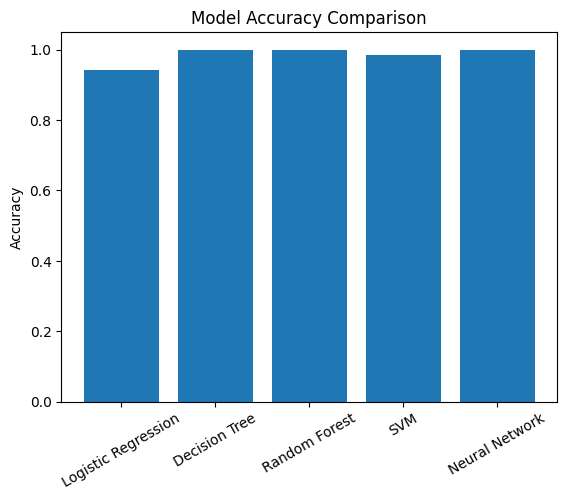

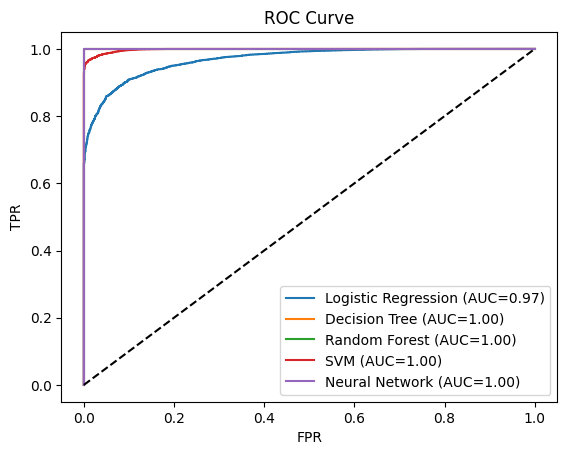


Best Model: Decision Tree
Model saved as best_model.pkl


In [ ]:
# ================================
# DIABETES RISK PREDICTION PROJECT
# ================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

import joblib


# 2. GENERATE LARGE DATASET (100K rows)
np.random.seed(42)

n = 100000

df = pd.DataFrame({
    'gender': np.random.choice([0, 1], n),
    'age': np.random.randint(18, 80, n),
    'hypertension': np.random.choice([0, 1], n),
    'heart_disease': np.random.choice([0, 1], n),
    'smoking_history': np.random.randint(0, 5, n),
    'bmi': np.random.uniform(15, 40, n),
    'HbA1c_level': np.random.uniform(4, 10, n),
    'blood_glucose_level': np.random.randint(70, 300, n)
})

# Target variable
df['diabetes'] = (
    (df['bmi'] > 30) |
    (df['HbA1c_level'] > 6.5) |
    (df['blood_glucose_level'] > 180)
).astype(int)

print("Dataset Shape:", df.shape)


# 3. EXPLORATORY DATA ANALYSIS (EDA)
plt.figure()
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()

plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


# 4. PREPROCESSING
X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 5. DEFINE MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
}

results = {}
roc_data = {}


# 6. TRAIN + EVALUATE
for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # ROC
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_data[name] = (fpr, tpr, roc_auc)


# 7. ACCURACY COMPARISON GRAPH
plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


# 8. ROC CURVE
plt.figure()

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()


# 9. BEST MODEL
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)


# 10. SAVE MODEL
joblib.dump(models[best_model_name], "best_model.pkl")
print("Model saved as best_model.pkl")